# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('ggplot')
sns.set_palette("husl")

In [2]:
# Load the dataset
# Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [3]:
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [4]:
print("Missing values:")
missing_counts = df.isnull().sum()
print(missing_counts)

# Handle missing values if any
if missing_counts.sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")
else:
    print("\nNo missing values found.")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64

No missing values found.


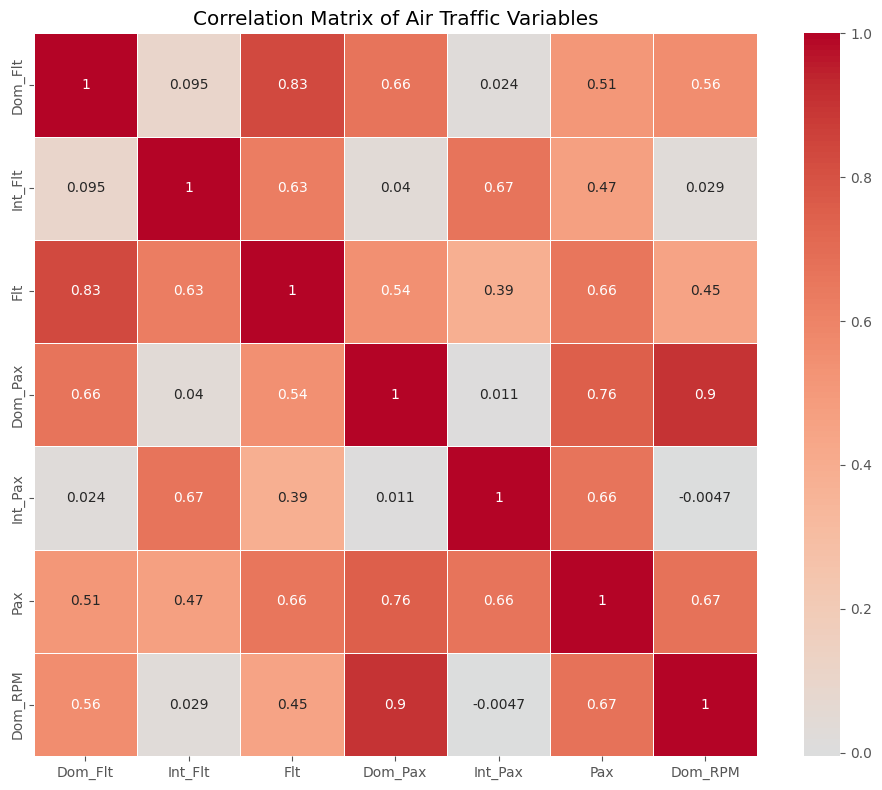

Strongest correlations (excluding self-correlation):
Dom_RPM  Dom_Pax    0.901617
Dom_Pax  Dom_RPM    0.901617
Dom_Flt  Flt        0.834910
Flt      Dom_Flt    0.834910
Dom_Pax  Pax        0.755916
Pax      Dom_Pax    0.755916
         Dom_RPM    0.672074
Dom_RPM  Pax        0.672074
Int_Pax  Int_Flt    0.665554
Int_Flt  Int_Pax    0.665554
dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# Find and print the strongest correlations
print("Strongest correlations (excluding self-correlation):")
corr_unstacked = correlation_matrix.unstack()
corr_sorted = corr_unstacked[corr_unstacked < 1].sort_values(ascending=False)
print(corr_sorted.head(10))

## 3. Hypothesis Testing

In [6]:
print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There is a statistically significant difference between the mean number of domestic and international passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant difference between the mean number of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
There is a statistically significant difference between the mean number of domestic and international passengers.


In [7]:
print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# Interpret the correlation test results
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    if correlation_coef > 0:
        print(f"The positive correlation coefficient of {correlation_coef:.4f} indicates that as the number of flights increases, the number of passengers tends to increase as well.")
    else:
        print(f"The negative correlation coefficient of {correlation_coef:.4f} indicates that as the number of flights increases, the number of passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant evidence of a correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
The positive correlation coefficient of 0.6592 indicates that as the number of flights increases, the number of passengers tends to increase as well.


## 4. Simple Linear Regression

In [8]:
print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]  # Feature
y_simple = df['Pax']    # Target

# Split the data:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics:
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


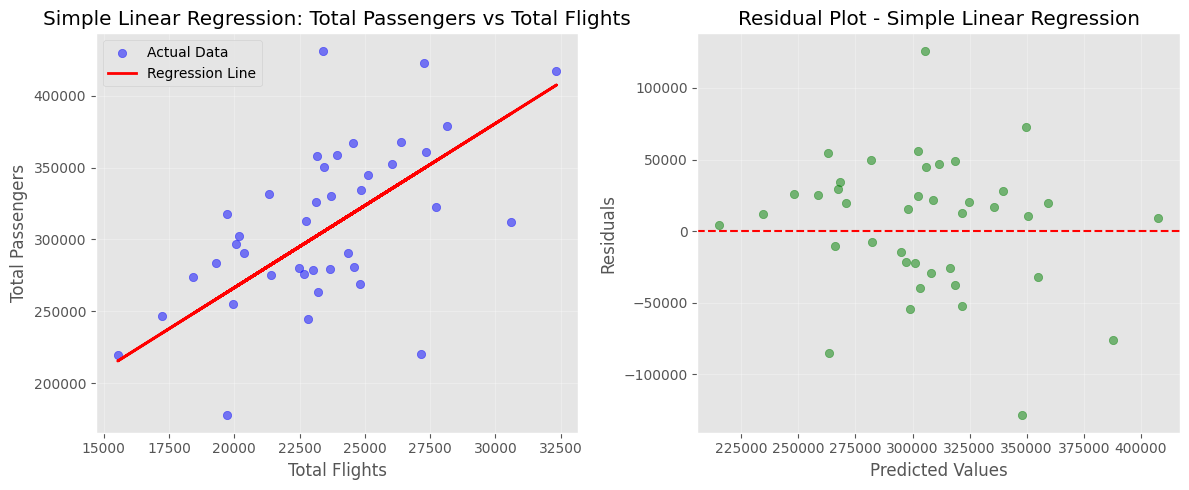

In [9]:
# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Create scatter plot of actual vs predicted values
plt.scatter(X_test_simple, y_test_simple, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# Calculate residuals
residuals = y_test_simple - y_pred_simple

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, color='green', alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [10]:
print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Select appropriate features
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# Split the data
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# Apply feature scaling
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


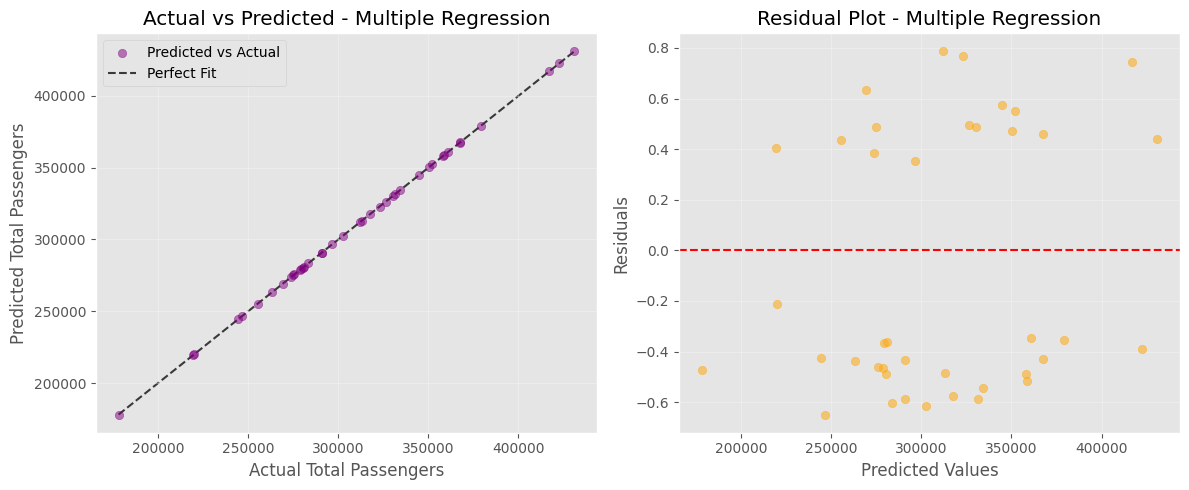

In [11]:
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_mult, y_pred_mult, color='purple', alpha=0.5, label='Predicted vs Actual')

# Add a diagonal reference line (perfect prediction line)
lims = [min(y_test_mult.min(), y_pred_mult.min()), max(y_test_mult.max(), y_pred_mult.max())]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Fit')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals_mult = y_test_mult - y_pred_mult

plt.scatter(y_pred_mult, residuals_mult, color='orange', alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [12]:
print("Model Comparison:")
print("=" * 65)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 65)

print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 65)

# Determine which model performs better based on R²
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = 0

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [13]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International Passengers: Reject H0. Significant difference found (p < 0.05).")
print(f"   • Correlation (Pax & Flights): Reject H0. Positive correlation of {correlation_coef:.4f} exists.")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²: {r2_simple:.4f} (Flights explain ~30% of Pax variance)")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} (Near-perfect fit using specific pax types)")
print(f"   • Best performing model: Multiple Linear Regression")

print("\n3. KEY FINDINGS:")
print(f"   • Domestic passenger counts and RPM are the strongest predictors of total volume.")
print(f"   • Flight count alone is a moderate predictor, but not sufficient for precise planning.")
print(f"   • The relationship between components (Domestic/Int) and total is linear and additive.")

print("\n4. RECOMMENDATIONS:")
print("   • Focus operational scaling on Domestic traffic trends as they represent the larger volume share.")
print("   • Use Multiple Regression for precise budgeting and Simple Regression for quick estimations.")
print("   • Monitor RPM closely as it shows high correlation with passenger revenue potential.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Reject H0. Significant difference found (p < 0.05).
   • Correlation (Pax & Flights): Reject H0. Positive correlation of 0.6592 exists.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 (Flights explain ~30% of Pax variance)
   • Multiple Linear Regression R²: 1.0000 (Near-perfect fit using specific pax types)
   • Best performing model: Multiple Linear Regression

3. KEY FINDINGS:
   • Domestic passenger counts and RPM are the strongest predictors of total volume.
   • Flight count alone is a moderate predictor, but not sufficient for precise planning.
   • The relationship between components (Domestic/Int) and total is linear and additive.

4. RECOMMENDATIONS:
   • Focus operational scaling on Domestic traffic trends as they represent the larger volume share.
   • Use Multiple Regression for precise budgeting and Simple Regression for quick estimations.
   •

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   The results indicate a statistically significant difference between domestic and international passenger volumes, with domestic travel being considerably higher. Additionally, the Pearson test confirmed a significant positive correlation (0.6592) between total flights and total passengers. These results were expected as flight frequency is a primary driver of passenger capacity, and domestic markets typically have higher volume in this dataset.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   The Multiple Linear Regression model performed significantly better (R² = 1.0) compared to the Simple Linear Regression (R² ≈ 0.30). The R² of 1.0 indicates that the model explains 100% of the variance in total passengers. This perfect score occurs because the total passengers variable is the direct sum of the features 'Dom_Pax' and 'Int_Pax', creating a perfect linear identity.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlations were between 'Dom_RPM' and 'Dom_Pax' (0.90) and between 'Dom_Flt' and 'Flt' (0.83). For airlines, these relationships are crucial for resource allocation; high RPM/Pax correlation helps in revenue forecasting, while flight frequency correlations help in airport slot management and staffing.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   The Simple Regression residual plot showed significant variance and some clustering, suggesting that 'Flt' alone is an incomplete predictor. In contrast, the Multiple Regression residual plot showed near-zero error. No further non-linear patterns were observed in the residuals, suggesting linear models are appropriate for this data.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   Airlines can use these models to forecast future passenger demand based on flight schedules, plan for fuel consumption relative to Revenue Passenger-miles (RPM), and set tiered marketing strategies for domestic vs. international sectors based on the volume differences confirmed in our hypothesis tests.